# <div align="center"><u>Naive Bayes High Pearson Correlation</u>

##############################################################################################################################

###  Import some useful libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import random
import time

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score

### Suppress warnings

In [2]:
# import warnings

# # To suppress all warnings
# warnings.filterwarnings("ignore")

### Start time

In [3]:
# Start time
start_time = time.time()

### Load the colon-kidney high pearson correlation filtered capped dataset and store it within a pandas DataFrame

In [4]:
# Load the dataset and store it withina  panda dataframe to handle it easier
df = pd.read_csv(r"C:\Users\user\Desktop\AUTH\Διπλωματική\Python\Dimensionality Reduction Methods\High Correlation Filters\Pearson Correlation\The colon-kidney high pearson correlation filtered capped dataset.csv")

# Print the dataset
df

,1555989_at,1560652_at,1569532_a_at,200740_s_at,201250_s_at,201542_at,202018_s_at,202284_s_at,202468_s_at,202804_at,...,230233_at,232075_at,234983_at,235201_at,238058_at,37152_at,41220_at,48580_at,Target,Tissue
0,996.5,65.9000,34.600,6744.90,1251.0,2742.9,19.9,1859.9,971.9,1540.8,...,642.7,1338.5,1096.2,1328.9,776.2,2491.7,7147.1000,1740.1,0.0,Kidney
1,256.4,27.2000,37.800,7136.55,3922.1,2549.5,65.0,2976.2,559.2,2251.7,...,462.6,1377.0,3055.7,123.6,1783.8,1275.2,16327.5875,1090.1,0.0,Kidney
2,458.8,251.4375,260.900,3829.70,1883.9,3294.8,120.9,1659.5,304.3,1485.9,...,1334.9,971.0,1099.8,1050.8,1128.2,1571.1,6690.9000,1273.8,0.0,Kidney
3,892.1,82.2000,52.800,4722.40,2769.6,2498.4,51.4,2682.4,1061.5,1420.3,...,1995.3,1032.8,1859.1,1369.6,937.7,1769.4,6865.6000,1430.2,0.0,Kidney
4,830.2,90.6000,66.900,4245.30,3166.8,3128.0,85.1,2344.0,1299.1,1708.6,...,1033.1,2434.4,2615.9,908.3,2424.5,1493.6,10411.0000,2027.2,0.0,Kidney
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541,265.6,29.3000,15.600,3714.90,2220.6,2002.5,12.9,1990.5,1586.5,1880.9,...,710.1,1242.3,1766.5,479.4,1076.8,2438.2,7755.0000,1563.0,1.0,Colon
542,368.6,130.0000,92.300,5789.90,1426.7,3110.0,14.4,930.4,1130.6,1756.3,...,2863.7,2116.4,1533.0,133.2,1133.0,1827.5,9934.7000,1418.1,1.0,Colon
543,459.2,56.3000,321.575,5267.00,970.7,2510.7,54.5,1929.8,1204.1,2263.0,...,1268.1,1299.6,1367.2,289.0,1027.7,1831.6,9837.6000,2379.7,1.0,Colon
544,457.7,93.7000,85.600,2725.90,865.4,2650.6,16.0,3191.4,1140.2,1974.0,...,671.1,1954.4,2054.8,628.8,1315.6,2077.2,10719.9000,2245.5,1.0,Colon


### Define parameters

In [5]:
# Define parameters
number_of_splits = 50       # Number of MCCV iterations
test_size = 0.25            # 25% test data

### Prepare data

In [6]:
# Prepare data
X = df.iloc[:, :-2].values  # Features
y = df['Target'].values     # Classes-Labels

### Function that applies Monte Carlo Cross Validation (MCCV)

In [7]:
# Function that applies Monte Carlo Cross Validation
def NaiveBayes_MCCV(X, y, test_size=test_size, num_splits=number_of_splits):
    
    train_scores = np.zeros(num_splits)
    test_scores = np.zeros(num_splits)
    train_losses = np.zeros(num_splits)
    test_losses = np.zeros(num_splits)

    test_precision_scores = np.zeros(num_splits)
    test_recall_scores = np.zeros(num_splits)
    test_f1_scores = np.zeros(num_splits)
    test_auc_roc_scores = np.zeros(num_splits)

    # Get number of classes
    labels = np.unique(y)
    n_classes = len(labels)

    # Initialize accumulator for confusion matrices
    cm_total = np.zeros((n_classes, n_classes), dtype=np.float64)

    for i in range(num_splits):
        x_train, x_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, shuffle=True, stratify=y, random_state=i
        )

        model = GaussianNB()
        model.fit(x_train, y_train)

        y_train_pred = model.predict(x_train)
        y_test_pred = model.predict(x_test)
        y_train_proba = model.predict_proba(x_train)
        y_test_proba = model.predict_proba(x_test)

        train_scores[i] = accuracy_score(y_train, y_train_pred)
        test_scores[i] = accuracy_score(y_test, y_test_pred)
        train_losses[i] = log_loss(y_train, y_train_proba)
        test_losses[i] = log_loss(y_test, y_test_proba)

        # Calculate and store precision, recall, f1_score and AUC-ROC metrics for the test set
        test_precision_scores[i] = precision_score(y_test, y_test_pred, average='weighted', labels=labels, zero_division=0)
        test_recall_scores[i] = recall_score(y_test, y_test_pred, average='weighted', labels=labels, zero_division=0)
        test_f1_scores[i] = f1_score(y_test, y_test_pred, average='weighted', labels=labels, zero_division=0)
        test_auc_roc_scores[i] = roc_auc_score(y_test, y_test_proba[:, 1])

        # Add normalized confusion matrix to accumulator
        cm = confusion_matrix(y_test, y_test_pred, labels=labels)
        cm_total += cm

    # Average confusion matrix
    cm_avg = cm_total / num_splits

    return (
        train_scores,
        test_scores,
        train_losses,
        test_losses,
        test_precision_scores,
        test_recall_scores,
        test_f1_scores,
        test_auc_roc_scores,
        cm_avg,
        labels,
    )

### Apply MCCV

In [8]:
# Apply MCCV
train_scores, test_scores, train_losses, test_losses, \
test_precision_scores, test_recall_scores, test_f1_scores, test_auc_roc_scores, \
cm_avg, labels = NaiveBayes_MCCV(
    X, y, test_size=test_size, num_splits=number_of_splits
)

### Print results

In [9]:
print(f"Avg Training Accuracy: {np.mean(train_scores):.4f} ± {np.std(train_scores):.4f}")
print(f"Avg Evaluation Accuracy: {np.mean(test_scores):.4f} ± {np.std(test_scores):.4f}")

Avg Training Accuracy: 0.9165 ± 0.0071
Avg Evaluation Accuracy: 0.8947 ± 0.0254


In [10]:
print(f"Avg Training Log Loss: {np.mean(train_losses):.4f} ± {np.std(train_losses):.4f}")
print(f"Avg Evaluation Log Loss: {np.mean(test_losses):.4f} ± {np.std(test_losses):.4f}")

Avg Training Log Loss: 0.2950 ± 0.0220
Avg Evaluation Log Loss: 0.4120 ± 0.1323


In [11]:
print(f"Avg Evaluation Precision: {np.mean(test_precision_scores):.4f} ± {np.std(test_precision_scores):.4f}")
print(f"Avg Evaluation Recall:    {np.mean(test_recall_scores):.4f} ± {np.std(test_recall_scores):.4f}")
print(f"Avg Evaluation F1-Score:  {np.mean(test_f1_scores):.4f} ± {np.std(test_f1_scores):.4f}")
print(f"Avg Evaluation AUC-ROC:   {np.mean(test_auc_roc_scores):.4f} ± {np.std(test_auc_roc_scores):.4f}")

Avg Evaluation Precision: 0.8968 ± 0.0253
Avg Evaluation Recall:    0.8947 ± 0.0254
Avg Evaluation F1-Score:  0.8948 ± 0.0254
Avg Evaluation AUC-ROC:   0.9564 ± 0.0167


### Accuracy over MCCV iterations

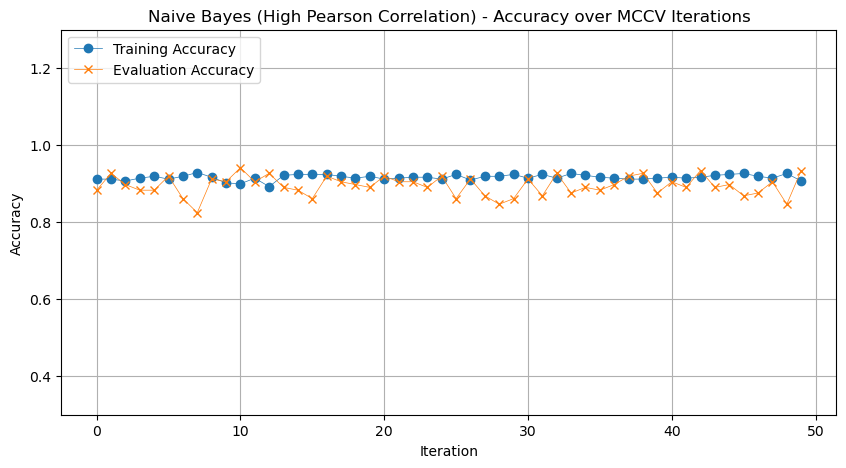

In [12]:
# Accuracy over MCCV iterations
plt.figure(figsize=(10, 5))
plt.plot(train_scores, label='Training Accuracy', marker='o', linewidth=0.5)
plt.plot(test_scores, label='Evaluation Accuracy', marker='x', linewidth=0.5)
plt.title("Naive Bayes (High Pearson Correlation) - Accuracy over MCCV Iterations")
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.legend(loc='upper left')
plt.ylim(0.3, 1.3)
plt.show()

### Log loss over MCCV iterations

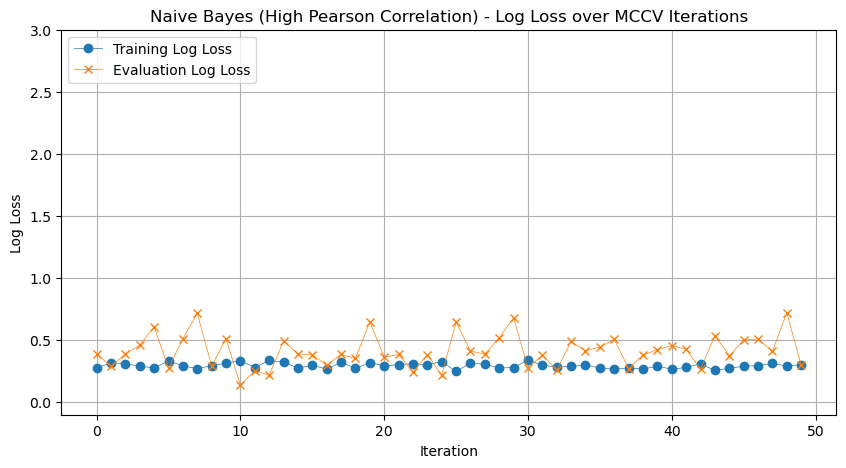

In [13]:
# Log loss over MCCV iterations
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Log Loss', marker='o', linewidth=0.5)
plt.plot(test_losses, label='Evaluation Log Loss', marker='x', linewidth=0.5)
plt.title("Naive Bayes (High Pearson Correlation) - Log Loss over MCCV Iterations")
plt.xlabel("Iteration")
plt.ylabel("Log Loss")
plt.legend()
plt.grid(True)
plt.legend(loc='upper left')
plt.ylim(-0.1, 3.0)
plt.show()

### Plot the average confussion matrix

In [14]:
# Function that plots the average confussion matrix
def plot_confusion_matrix(cm, labels, title='Naive Bayes (High Pearson Correlation) MCCV - Average Confusion Matrix', cmap='Blues'):
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap=cmap,
                xticklabels=labels,
                yticklabels=labels)

    plt.title(title, fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.tight_layout()
    plt.show()

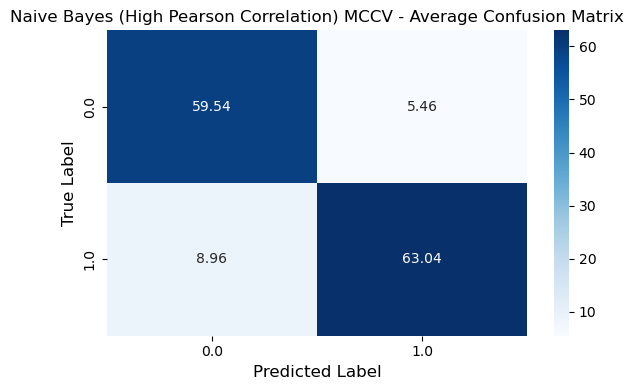

In [15]:
# Plot confusion matrix
plot_confusion_matrix(cm_avg, labels)

### End time

In [16]:
# End time
end_time = time.time()

### Elapsed time

In [17]:
# Elapsed time
elapsed_time = end_time - start_time

print(f"Elapsed time for Naive Bayes (High Pearson Correlation): {elapsed_time:.2f} seconds")

Elapsed time for Naive Bayes (High Pearson Correlation): 1.33 seconds
